# 📈 SIÊU PHÂN TÍCH CỔ PHIẾU (JUPYTER PRO MAX)

## Nâng cấp Mới nhất:
- 🧠 **Chuyên gia AI**: Khôi phục lại bộ não phân tích chuyên sâu (Chấm điểm sức mạnh, Khuyến nghị hành động).
- 🛡️ **Dữ liệu Đa tầng**: Sửa lỗi Scraper để bắt dữ liệu nhạy hơn.
- 📊 **Trực quan hóa**: Biểu đồ Plotly tương tác.

---

In [68]:
# 1. IMPORT & CẤU HÌNH
import warnings
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from vnstock import Vnstock
from datetime import datetime, timedelta
import requests
import re

warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None

print("✅ Hệ thống đã sẵn sàng!")

✅ Hệ thống đã sẵn sàng!


In [69]:
# 2. MODULE DỮ LIỆU (ROBUST FETCHER)

class RobustDataFetcher:
    def __init__(self, symbol):
        self.symbol = symbol.upper()
        self.headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) Chrome/91.0.4472.124 Safari/537.36'}

    def get_price_history(self, days=730):
        try:
            end = datetime.now().strftime('%Y-%m-%d')
            start = (datetime.now() - timedelta(days=days)).strftime('%Y-%m-%d')
            stock = Vnstock().stock(symbol=self.symbol, source='VCI')
            df = stock.quote.history(start=start, end=end, interval='1D')
            if df is not None and not df.empty:
                if isinstance(df.columns, pd.MultiIndex):
                    df.columns = ['_'.join(map(str, col)).strip() for col in df.columns.values]
                return df
        except Exception as e:
            print(f"❌ Lỗi giá: {e}")
        return pd.DataFrame()

    def scrape_cafef_overview(self):
        # Thử CafeF
        try:
            url = f"https://s.cafef.vn/hose/{self.symbol}.chn"
            resp = requests.get(url, headers=self.headers, verify=False, timeout=10)
            if resp.status_code == 200:
                html = resp.text
                data = {}
                # Regex linh hoạt hơn
                pe_match = re.search(r'P/E<\/td>.*?<span.*?>(.*?)<\/span>', html, re.DOTALL)
                if not pe_match:
                    pe_match = re.search(r'P/E<\/td>.*?class="dlt-right".*?>\s*([\d\.,]+)', html, re.DOTALL)
                
                if pe_match:
                     val = pe_match.group(1).replace(',', '').strip()
                     if val and val != 'N/A': data['pe'] = float(val)
                
                return data
        except:
            pass
        return {}

    def get_fundamentals(self):
        # 1. API
        for src in ['TCBS', 'SSI']:
            try:
                stock = Vnstock().stock(symbol=self.symbol, source=src)
                df = stock.finance.ratio(period='year', lang='vi')
                if df is not None and not df.empty:
                     if isinstance(df.columns, pd.MultiIndex):
                        df.columns = ['_'.join(map(str, col)).strip() for col in df.columns.values]
                     cols = [c.lower() for c in df.columns]
                     if any('pe' in c for c in cols):
                         return df.iloc[0].to_dict()
            except:
                continue
        
        # 2. Scraper
        print("⚠️ Đang kích hoạt Scraper dự phòng...")
        return self.scrape_cafef_overview()

In [70]:
# 3. MODULE KỸ THUẬT & CHUYÊN GIA AI

class TechnicalAnalyzer:
    @staticmethod
    def add_indicators(df):
        if df.empty: return df
        data = df.copy()
        rename_map = {c: c.lower() for c in data.columns}
        for k, v in rename_map.items():
            if 'close' in v: rename_map[k] = 'close'
            elif 'high' in v: rename_map[k] = 'high'
            elif 'low' in v: rename_map[k] = 'low'
            elif 'open' in v: rename_map[k] = 'open'
            elif 'volume' in v: rename_map[k] = 'volume'
        data.rename(columns=rename_map, inplace=True)
        
        data['ma20'] = data['close'].rolling(20).mean()
        data['ma50'] = data['close'].rolling(50).mean()
        data['ma200'] = data['close'].rolling(200).mean()
        
        std = data['close'].rolling(20).std()
        data['bb_up'] = data['ma20'] + 2 * std
        data['bb_lo'] = data['ma20'] - 2 * std
        
        delta = data['close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
        rs = gain / loss.replace(0, np.nan)
        data['rsi'] = 100 - (100 / (1 + rs))
        
        high_9 = data['high'].rolling(9).max(); low_9 = data['low'].rolling(9).min()
        data['tenkan'] = (high_9 + low_9) / 2
        high_26 = data['high'].rolling(26).max(); low_26 = data['low'].rolling(26).min()
        data['kijun'] = (high_26 + low_26) / 2
        
        data['senkou_a'] = ((data['tenkan'] + data['kijun']) / 2).shift(26)
        high_52 = data['high'].rolling(52).max(); low_52 = data['low'].rolling(52).min()
        data['senkou_b'] = ((high_52 + low_52) / 2).shift(26)
        
        return data

class ExpertAdvisor:
    @staticmethod
    def generate_report(df, fund_data, symbol):
        last = df.iloc[-1]
        score = 0
        details = []
        
        # 1. Trend Analysis
        trend_status = "KHÔNG RÕ"
        if last['close'] > last['ma20'] > last['ma50']:
            score += 3
            trend_status = "UPTREND (Tăng mạnh)"
            details.append("✅ Giá > MA20 > MA50 (Xu hướng tăng ngắn & trung hạn)")
        elif last['close'] < last['ma20'] < last['ma50']:
            score -= 3
            trend_status = "DOWNTREND (Giảm)"
            details.append("⚠️ Giá < MA20 < MA50 (Xu hướng giảm)")
        elif last['close'] > last['ma200']:
            score += 1
            trend_status = "TÍCH LŨY / UP DÀI HẠN"
            details.append("✅ Giá nằm trên MA200 (Hỗ trợ dài hạn tốt)")
        else:
            score -= 1
            trend_status = "YẾU / DƯỚI MA200"
            details.append("⚠️ Giá mất mốc MA200 (Rủi ro dài hạn)")
            
        # 2. Indicators Analysis
        # RSI
        if last['rsi'] < 30:
            score += 2
            details.append(f"✅ RSI Quá bán ({last['rsi']:.1f}) -> Cơ hội hồi phục")
        elif last['rsi'] > 70:
            score -= 2
            details.append(f"⚠️ RSI Quá mua ({last['rsi']:.1f}) -> Cẩn trọng chỉnh")
        
        # Bollinger
        if last['close'] <= last['bb_lo'] * 1.01:
            score += 1.5
            details.append("✅ Giá chạm dải dưới Bollinger (Vùng hỗ trợ động)")
        elif last['close'] >= last['bb_up'] * 0.99:
            score -= 1.5
            details.append("⚠️ Giá chạm dải trên Bollinger (Kháng cự)")
            
        # 3. Fundamentals
        pe = fund_data.get('pe', 0) or fund_data.get('priceToEarning', 0)
        if pe:
            if pe < 12:
                score += 2
                details.append(f"✅ P/E hấp dẫn ({pe:.1f}x < 12)")
            elif pe > 20:
                score -= 1
                details.append(f"⚠️ P/E khá cao ({pe:.1f}x > 20)")
        else:
            details.append("ℹ️ Chưa đủ dữ liệu P/E để đánh giá")
            
        # 4. Conclusion
        recommendation = "THEO DÕI"
        color = "🟡"
        if score >= 4: recommendation = "MUA MẠNH"; color = "🟢"
        elif score >= 1: recommendation = "MUA TÍCH LŨY"; color = "🔵"
        elif score <= -3: recommendation = "BÁN / HẠ TỶ TRỌNG"; color = "🔴"
        
        # --- PRINT REPORT ---
        print("\n" + "="*60)
        print(f"📢 BÁO CÁO CHUYÊN GIA: {symbol}")
        print("="*60)
        print(f"🔥 ĐIỂM SỨC MẠNH: {score:.1f}/10")
        print(f"{color} KHUYẾN NGHỊ: {recommendation}")
        
        print(f"\n📊 XU HƯỚNG: {trend_status}")
        print(f"   • Giá hiện tại: {last['close']:,.0f}")
        print(f"   • Hỗ trợ (MA200): {last['ma200']:,.0f}")
        print(f"   • RSI (14): {last['rsi']:.1f}")
        print(f"   • P/E (Cơ bản): {pe if pe else 'N/A'}")
        
        print("\n🔍 LUẬN ĐIỂM CHI TIẾT:")
        for d in details:
            print(f"   {d}")
        print("="*60)

🚀 Đang xử lý dữ liệu cho FPT...


2026-01-27 14:00:45 - vnstock.common.data - INFO - TCBS listing data fallback to VCI
2026-01-27 14:00:45 - vnstock.common.data - WARNING - TCBS only supports Vietnamese reports
2026-01-27 14:00:46 - vnstock.explorer.tcbs.financial - ERROR - Error retrieving financial ratios for FPT: Failed to fetch data: 401 - Unauthorized


⚠️ Đang kích hoạt Scraper dự phòng...

📢 BÁO CÁO CHUYÊN GIA: FPT
🔥 ĐIỂM SỨC MẠNH: 3.0/10
🔵 KHUYẾN NGHỊ: MUA TÍCH LŨY

📊 XU HƯỚNG: UPTREND (Tăng mạnh)
   • Giá hiện tại: 102
   • Hỗ trợ (MA200): 99
   • RSI (14): 58.9
   • P/E (Cơ bản): N/A

🔍 LUẬN ĐIỂM CHI TIẾT:
   ✅ Giá > MA20 > MA50 (Xu hướng tăng ngắn & trung hạn)
   ℹ️ Chưa đủ dữ liệu P/E để đánh giá


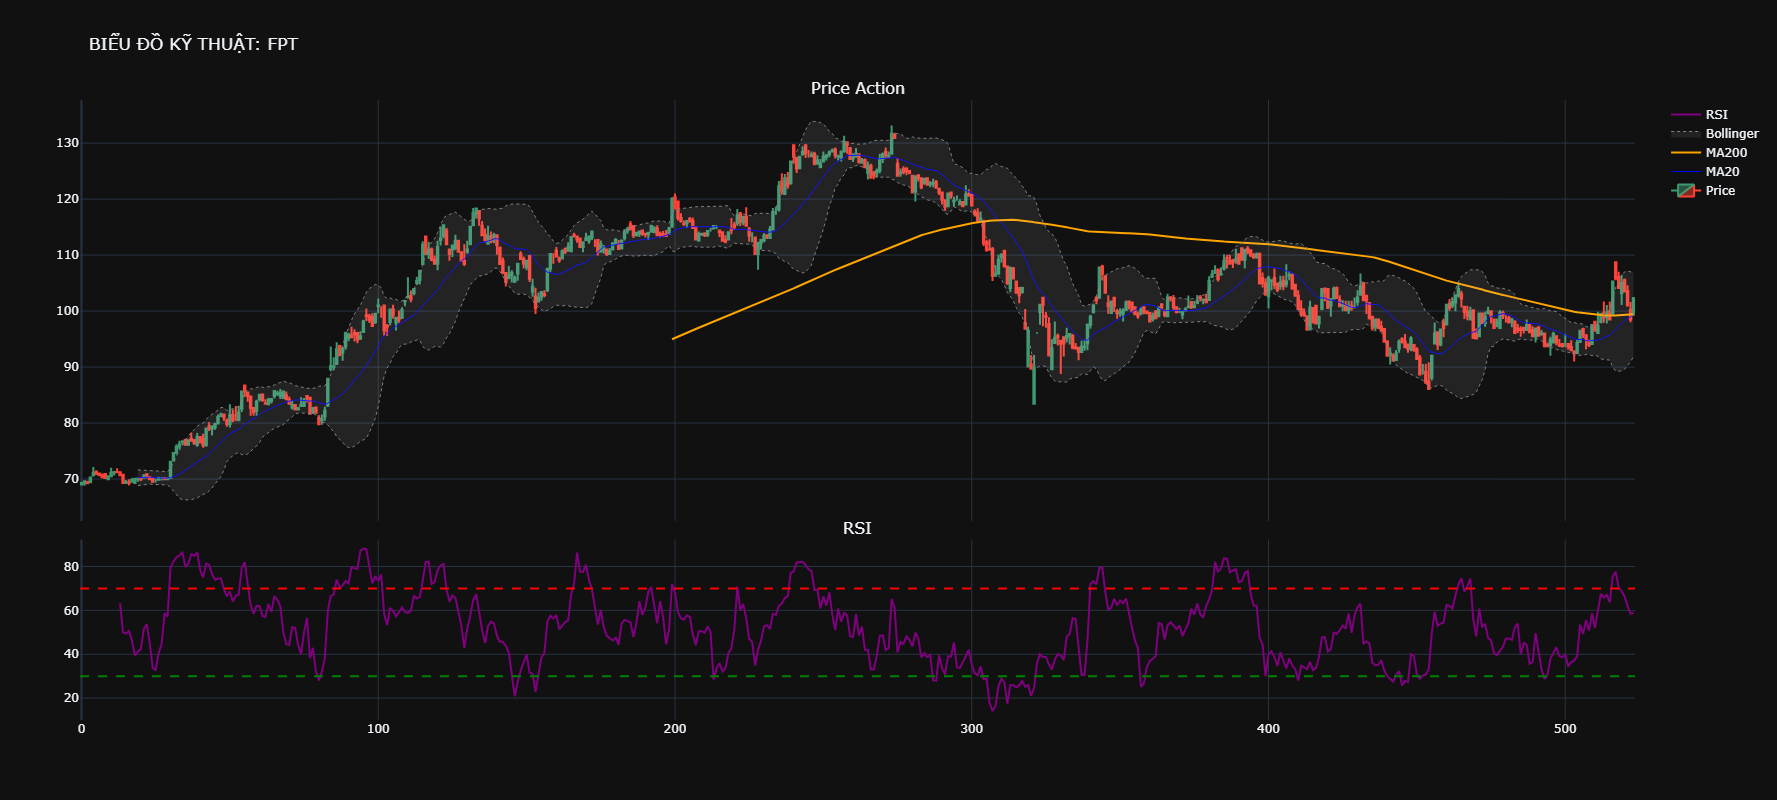

In [71]:
# 4. CHẠY PHÂN TÍCH (NHẬP MÃ VIDEO NÀY)
SYMBOL = "FPT" # <--- THAY MÃ CP VÀO ĐÂY

print(f"🚀 Đang xử lý dữ liệu cho {SYMBOL}...")
fetcher = RobustDataFetcher(SYMBOL)
price_df = fetcher.get_price_history()
fund_data = fetcher.get_fundamentals()

if not price_df.empty:
    df = TechnicalAnalyzer.add_indicators(price_df)
    
    # 1. In Báo Cáo Chuyên Gia (TEXT)
    ExpertAdvisor.generate_report(df, fund_data, SYMBOL)
    
    # 2. Vẽ Biểu Đồ (PLOTLY)
    fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.03, 
                        row_heights=[0.7, 0.3], subplot_titles=("Price Action", "RSI"))
    
    fig.add_trace(go.Candlestick(x=df.index, open=df['open'], high=df['high'], 
                                 low=df['low'], close=df['close'], name='Price'), row=1, col=1)
    fig.add_trace(go.Scatter(x=df.index, y=df['ma20'], line=dict(color='blue', width=1), name='MA20'), 1, 1)
    fig.add_trace(go.Scatter(x=df.index, y=df['ma200'], line=dict(color='orange', width=2), name='MA200'), 1, 1)
    fig.add_trace(go.Scatter(x=df.index, y=df['bb_up'], line=dict(color='gray', width=1, dash='dot'), showlegend=False), 1, 1)
    fig.add_trace(go.Scatter(x=df.index, y=df['bb_lo'], line=dict(color='gray', width=1, dash='dot'), 
                             fill='tonexty', fillcolor='rgba(200,200,200,0.1)', name='Bollinger'), 1, 1)
    
    fig.add_trace(go.Scatter(x=df.index, y=df['rsi'], line=dict(color='purple', width=2), name='RSI'), 2, 1)
    fig.add_hline(y=70, line_dash="dash", line_color="red", row=2, col=1)
    fig.add_hline(y=30, line_dash="dash", line_color="green", row=2, col=1)
    
    fig.update_layout(height=800, template="plotly_dark", title_text=f"BIỂU ĐỒ KỸ THUẬT: {SYMBOL}", xaxis_rangeslider_visible=False)
    fig.show()
else:
    print("❌ Không có dữ liệu giá!")